# 1. Thư viện và dữ liệu

In [1]:
import pandas as pd
from src.processing.aggregate import prepare_level_data
from src.model.prophet import ProphetModel
from src.model.arima import ARIMAModel


D:\Data\uel\HK7\Sources\Mortality_Rate_Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "../data/time_series_country.csv"
df = pd.read_csv(file_path, sep=",", engine="python")


# 2.Dự báo tỷ lệ tử vong

## 2.1. Global model

In [3]:
global_df = prepare_level_data(df, level="global")
global_model = ARIMAModel(global_df)

In [4]:
forecast_df =global_model.arima_forecast(0, 1, 0, steps=6)
print(forecast_df)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              1.097062  1.871337      -2.570691       4.764815
26              1.097062  2.646470      -4.089924       6.284048
27              1.097062  3.241250      -5.255672       7.449796
28              1.097062  3.742674      -6.238444       8.432567
29              1.097062  4.184436      -7.104283       9.298406
30              1.097062  4.583820      -7.887061      10.081185


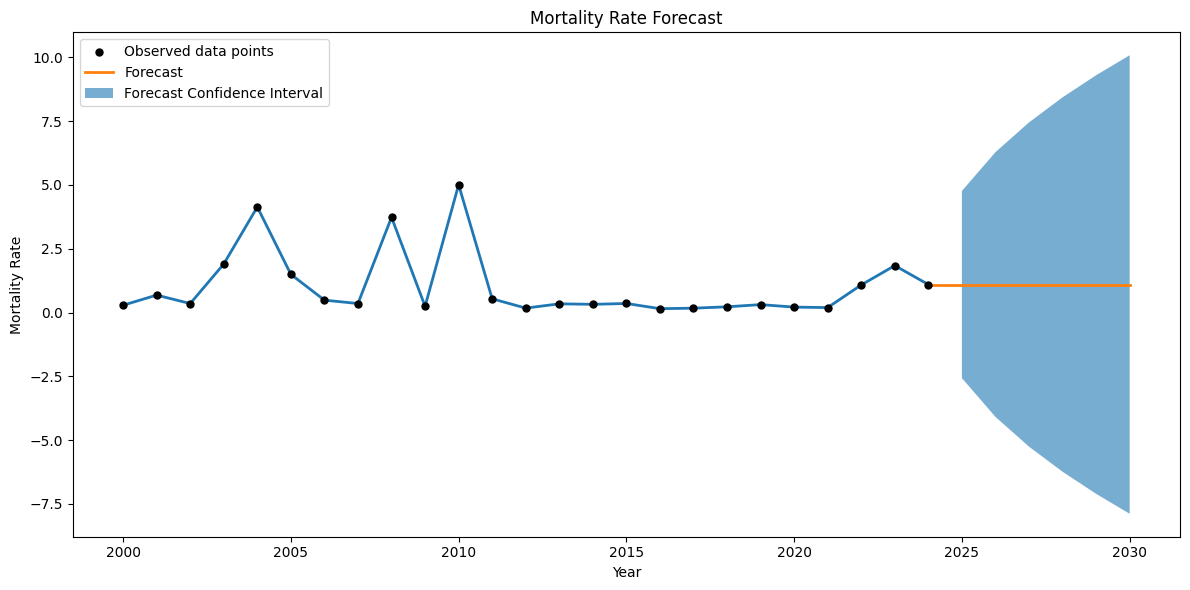

In [5]:
global_model.plot_forecast(0, 1, 0, steps=6)

## 2.2. Region Level

### 2.2.1. South Asia

In [6]:
south_asia = prepare_level_data(df,level='region', filter='South Asia')
south_asia_model = ARIMAModel(south_asia)
south_asia_forecast = south_asia_model.arima_forecast(0, 1, 1, steps=6)

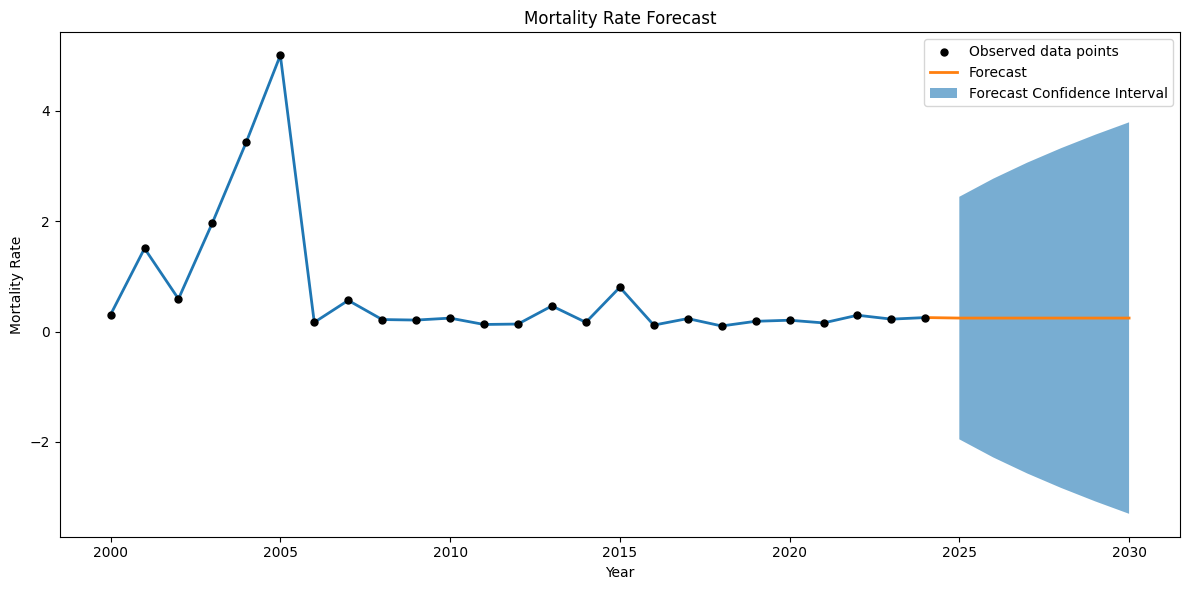

In [7]:
south_asia_model.plot_forecast(0, 1, 1, steps=6)

### 2.2.2. Europe and Central Asia

In [8]:
europe_central_asia= prepare_level_data(df,level='region', filter='Europe and Central Asia')
europe_central_asia_model = ProphetModel(europe_central_asia)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2003, 2010, 2022, 2023, 2024]
europe_central_asia_forecast = europe_central_asia_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(europe_central_asia_forecast)

23:11:28 - cmdstanpy - INFO - Chain [1] start processing
23:11:28 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.192328   -1.144761    0.777961
26 2026-12-31 -0.222577   -1.167337    0.759407
27 2027-12-31 -0.252825   -1.252208    0.760320
28 2028-12-31 -0.283157   -1.236954    0.655095
29 2029-12-31 -0.313405   -1.295161    0.550615
30 2030-12-31 -0.343654   -1.275215    0.583738


23:11:29 - cmdstanpy - INFO - Chain [1] start processing
23:11:29 - cmdstanpy - INFO - Chain [1] done processing


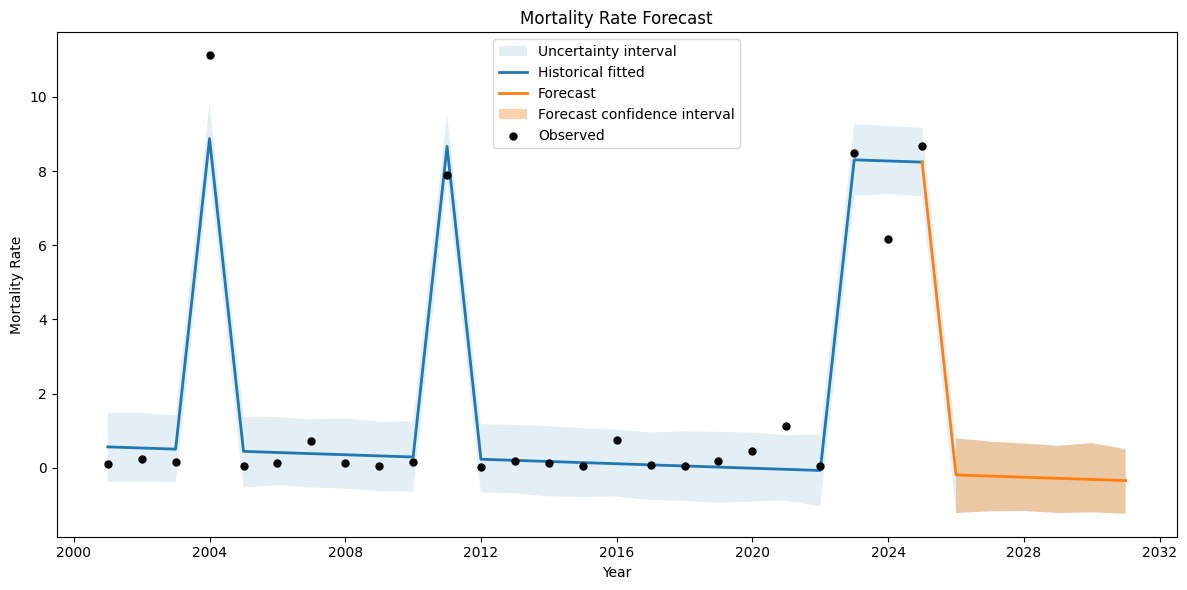

In [9]:
europe_central_asia_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.3. Middle East and North Africa

In [10]:
middle_east_north_africa = prepare_level_data(df,level='region', filter='Middle East and North Africa')
middle_east_north_africa_model = ARIMAModel(middle_east_north_africa)
middle_east_north_africa_forecast = middle_east_north_africa_model.arima_forecast(1, 0, 1, steps=6)
print(middle_east_north_africa_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25             -0.251009  4.610928      -9.288261       8.786243
26             -0.068071  4.639864      -9.162037       9.025895
27              0.089153  4.661122      -9.046477       9.224784
28              0.224278  4.676762      -8.942006       9.390562
29              0.340410  4.688280      -8.848450       9.529270
30              0.440218  4.696770      -8.765282       9.645718


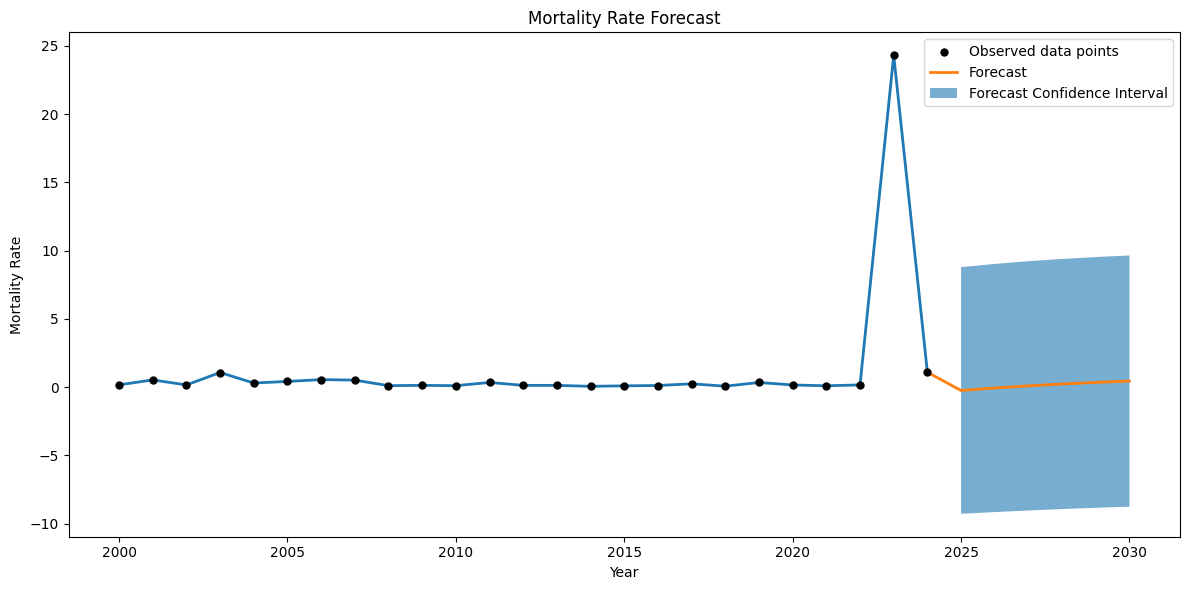

In [11]:
middle_east_north_africa_model.plot_forecast(1, 0, 1, steps=6)

### 2.2.4. East Asia and Pacific

In [12]:
east_asia_pacific = prepare_level_data(df,level='region', filter='East Asia and Pacific')
east_asia_pacific_model = ProphetModel(east_asia_pacific)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2004, 2008, 2011]
east_asia_pacific_forecast = east_asia_pacific_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(east_asia_pacific_forecast)

23:11:30 - cmdstanpy - INFO - Chain [1] start processing
23:11:30 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -0.122718   -1.987650    1.585807
26 2026-12-31 -0.148197   -1.908876    1.549884
27 2027-12-31 -0.173676   -1.896893    1.664322
28 2028-12-31 -0.199225   -2.039031    1.674644
29 2029-12-31 -0.224704   -2.133273    1.576274
30 2030-12-31 -0.250183   -2.083136    1.586969


23:11:30 - cmdstanpy - INFO - Chain [1] start processing
23:11:31 - cmdstanpy - INFO - Chain [1] done processing


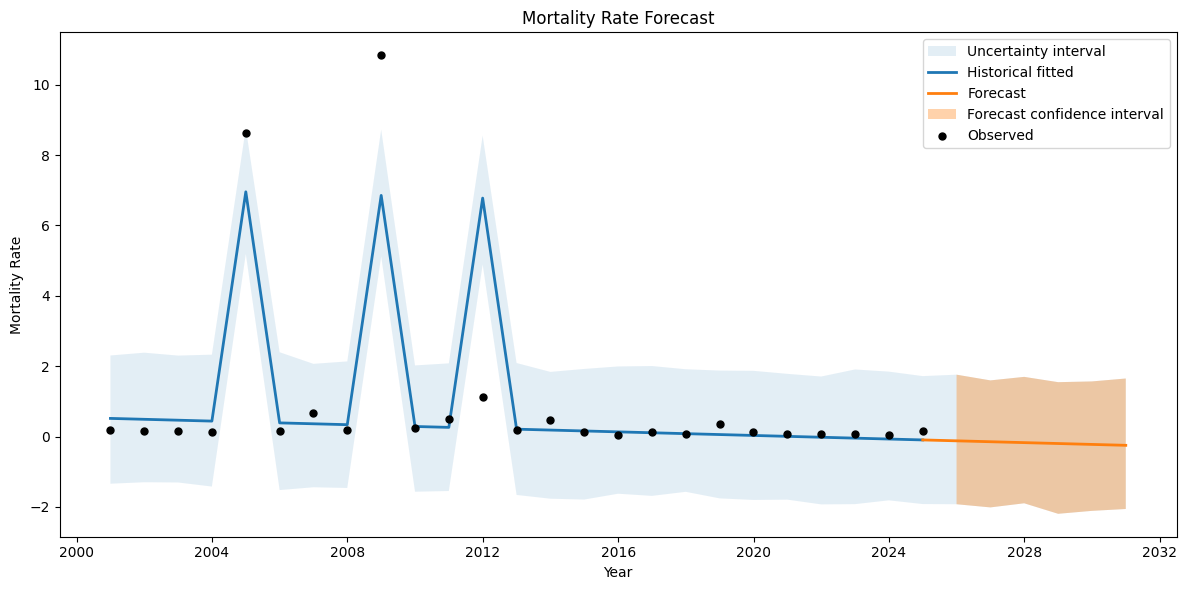

In [13]:
east_asia_pacific_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.5. Sub-Saharan Africa

In [14]:
subsaharan_africa = prepare_level_data(df,level='region', filter='Sub-Saharan Africa')
subsaharan_africa_model = ProphetModel(subsaharan_africa)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010, 2014]
subsaharan_africa_forecast = subsaharan_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(subsaharan_africa_forecast)

23:11:31 - cmdstanpy - INFO - Chain [1] start processing
23:11:31 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.610528    0.253701    0.974158
26 2026-12-31  0.636273    0.282239    0.993639
27 2027-12-31  0.662018    0.296190    0.999615
28 2028-12-31  0.687834    0.346022    1.039893
29 2029-12-31  0.713579    0.351676    1.078722
30 2030-12-31  0.739324    0.365062    1.090169


23:11:32 - cmdstanpy - INFO - Chain [1] start processing
23:11:32 - cmdstanpy - INFO - Chain [1] done processing


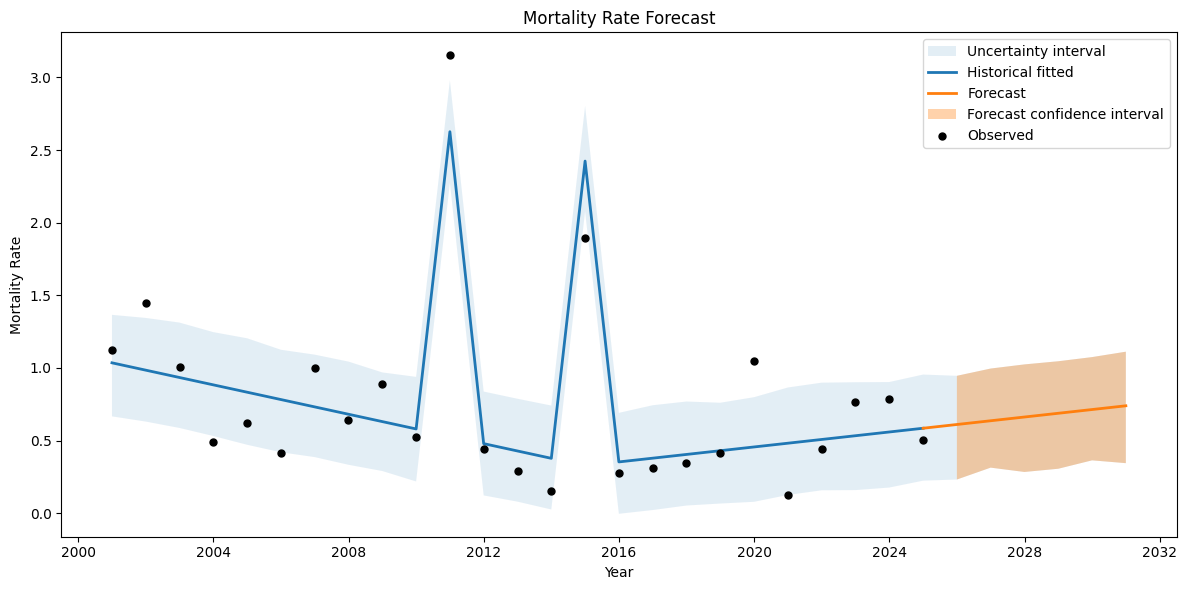

In [15]:
subsaharan_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.6. Latin America and Caribbean

In [16]:
latin_america_caribbean = prepare_level_data(df,level='region', filter='Latin America and Caribbean')
latin_america_caribbean_model = ProphetModel(latin_america_caribbean)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2010]
latin_america_caribbean_forecast = latin_america_caribbean_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(latin_america_caribbean_forecast)

23:11:33 - cmdstanpy - INFO - Chain [1] start processing
23:11:33 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.220883   -0.023021    0.443632
26 2026-12-31  0.222211   -0.015452    0.457469
27 2027-12-31  0.223538   -0.003279    0.472804
28 2028-12-31  0.224870   -0.048650    0.492330
29 2029-12-31  0.226197   -0.051196    0.488694
30 2030-12-31  0.227525   -0.067221    0.528954


23:11:33 - cmdstanpy - INFO - Chain [1] start processing
23:11:33 - cmdstanpy - INFO - Chain [1] done processing


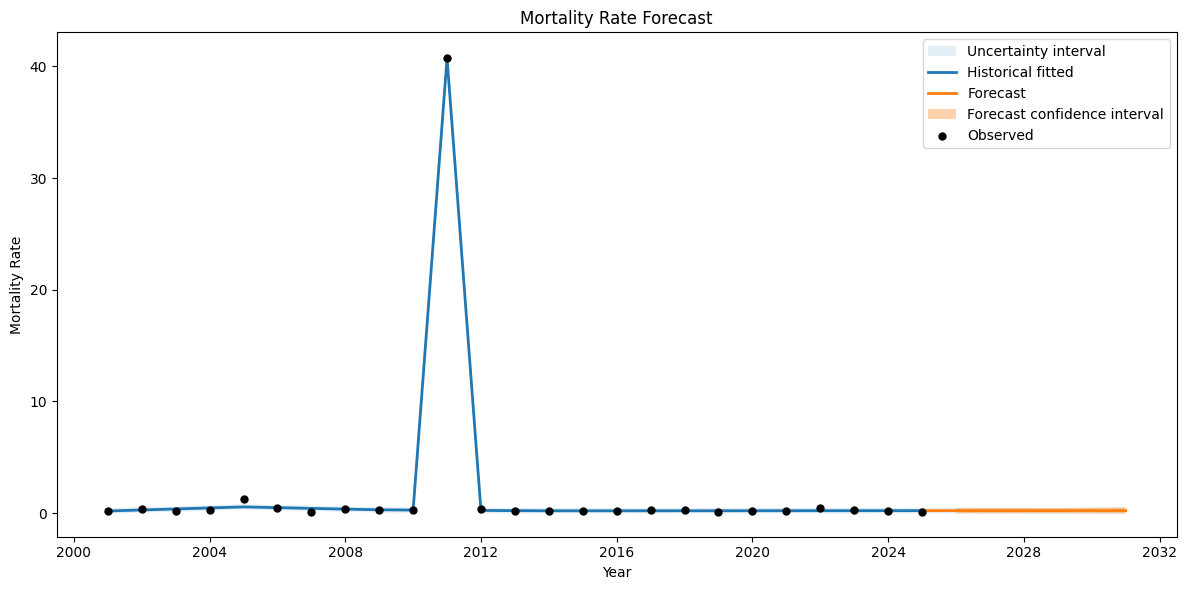

In [17]:
latin_america_caribbean_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.2.7. North America

In [18]:
north_america = prepare_level_data(df,level='region', filter='North America')
north_america_model = ProphetModel(north_america)
best_params = {
    "changepoint_prior_scale": float(0.5),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005,2011, 2021, 2024]
north_america_forecast = north_america_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(north_america_forecast)

23:11:34 - cmdstanpy - INFO - Chain [1] start processing
23:11:34 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.121115    0.054879    0.183848
26 2026-12-31  0.126725    0.064405    0.189615
27 2027-12-31  0.132334    0.073214    0.197830
28 2028-12-31  0.137960    0.068303    0.203592
29 2029-12-31  0.143569    0.076503    0.211919
30 2030-12-31  0.149179    0.075913    0.216666


23:11:35 - cmdstanpy - INFO - Chain [1] start processing
23:11:35 - cmdstanpy - INFO - Chain [1] done processing


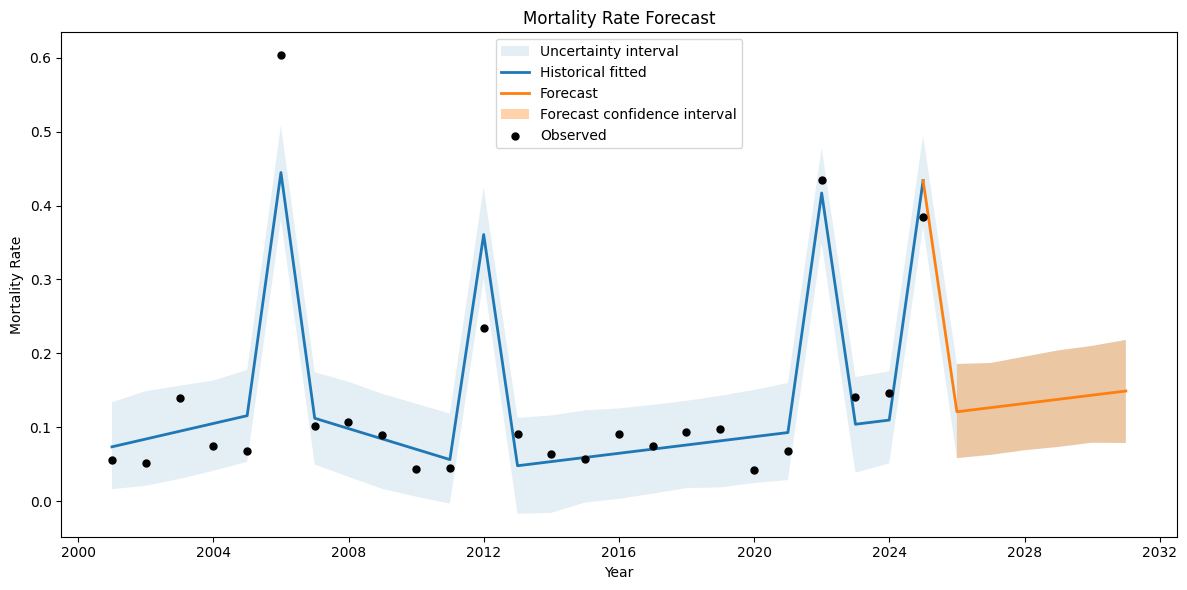

In [19]:
north_america_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

## 2.3. Country Level

### 2.3.1. Viet Nam

In [20]:
vietnam = prepare_level_data(df,level='country', filter='Viet Nam')
vietnam_model = ProphetModel(vietnam)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = []
vietnam_forecast = vietnam_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(vietnam_forecast)

23:11:36 - cmdstanpy - INFO - Chain [1] start processing
23:11:36 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.056955   -0.151122    0.271016
26 2026-12-31  0.040974   -0.148437    0.250466
27 2027-12-31  0.024993   -0.188700    0.218647
28 2028-12-31  0.008969   -0.209326    0.204916
29 2029-12-31 -0.007012   -0.218596    0.203154
30 2030-12-31 -0.022993   -0.231225    0.183872


23:11:36 - cmdstanpy - INFO - Chain [1] start processing
23:11:36 - cmdstanpy - INFO - Chain [1] done processing


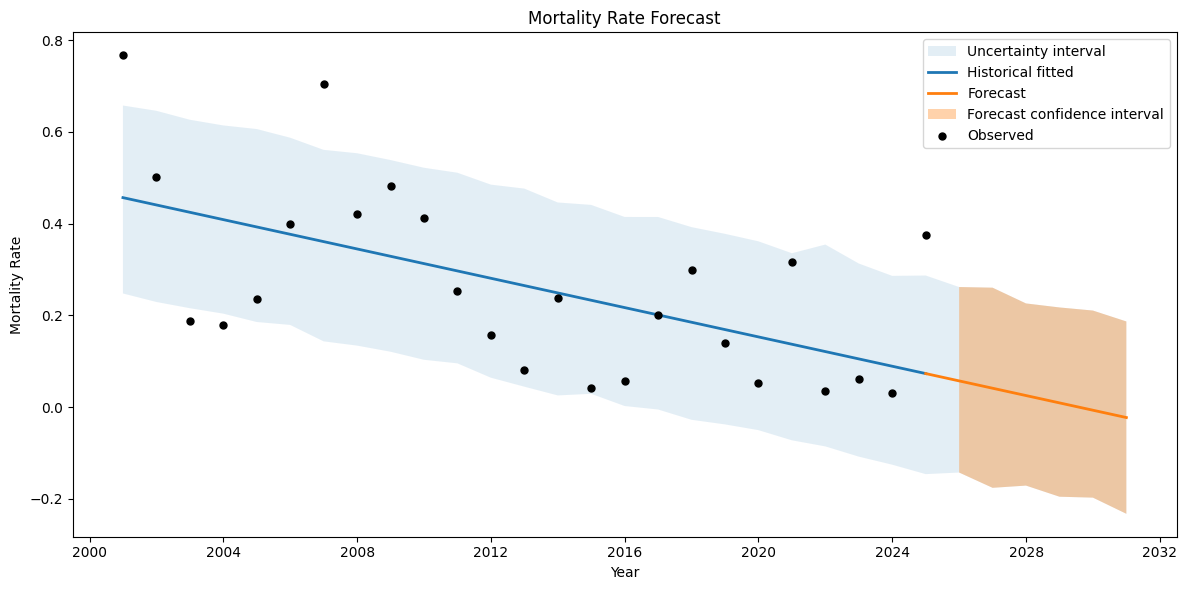

In [21]:
vietnam_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.2. Japan

In [22]:
japan = prepare_level_data(df,level='country', filter='Japan')
japan_model = ProphetModel(japan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
japan_forecast = japan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(japan_forecast)

23:11:37 - cmdstanpy - INFO - Chain [1] start processing
23:11:37 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.217020    0.074531    0.374528
26 2026-12-31  0.224105    0.072423    0.374153
27 2027-12-31  0.231189    0.069563    0.377161
28 2028-12-31  0.238292    0.081572    0.388549
29 2029-12-31  0.245377    0.099999    0.404411
30 2030-12-31  0.252461    0.110928    0.398773


23:11:37 - cmdstanpy - INFO - Chain [1] start processing
23:11:38 - cmdstanpy - INFO - Chain [1] done processing


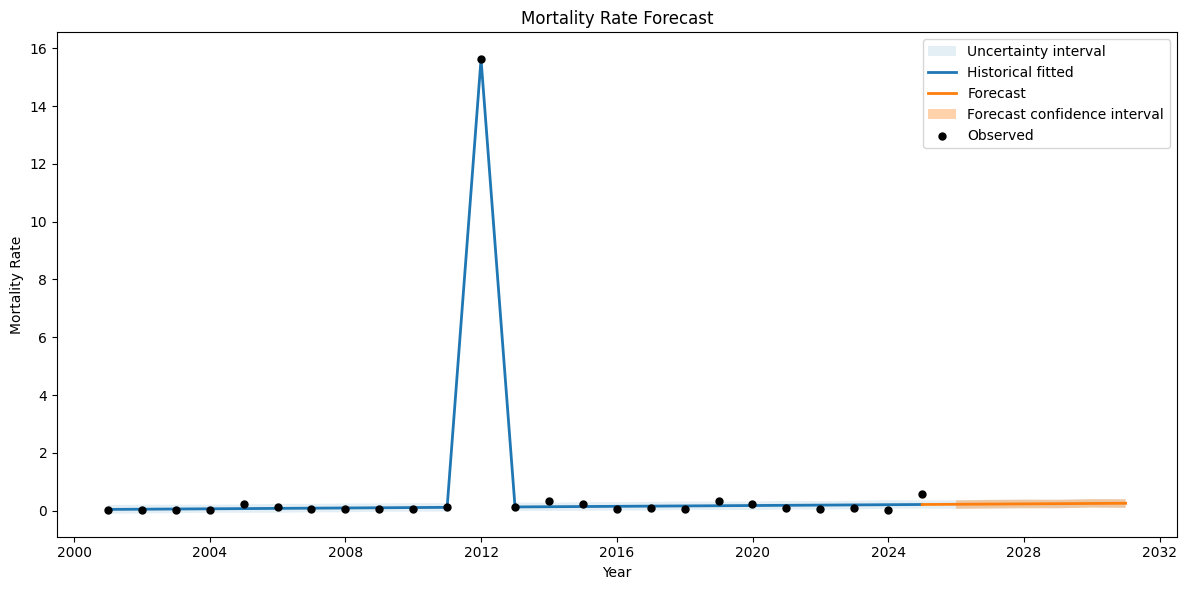

In [23]:
japan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.3. France

In [24]:
france = prepare_level_data(df,level='country', filter='France')
france_model = ARIMAModel(france)
france_forecast = france_model.arima_forecast(0, 0, 0, steps=6)
print(france_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              2.343283  6.216549      -9.840929      14.527495
26              2.343283  6.216549      -9.840929      14.527495
27              2.343283  6.216549      -9.840929      14.527495
28              2.343283  6.216549      -9.840929      14.527495
29              2.343283  6.216549      -9.840929      14.527495
30              2.343283  6.216549      -9.840929      14.527495


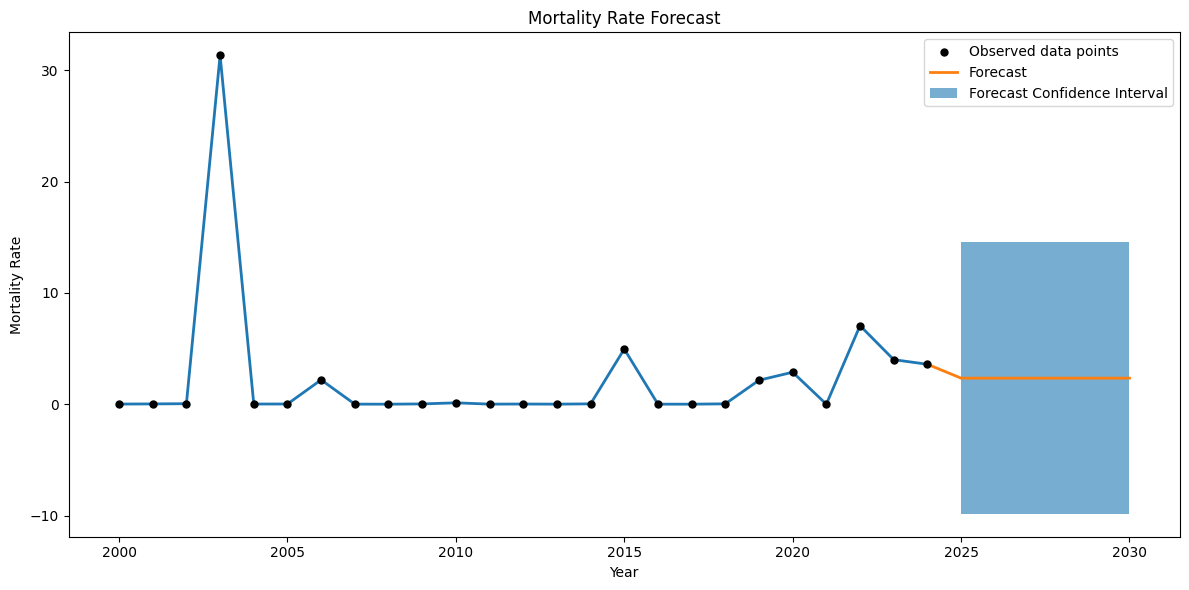

In [25]:
france_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.4. Italy

In [26]:
italy = prepare_level_data(df,level='country', filter='Italy')
italy_model = ProphetModel(italy)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(10.0)
}
holiday_years = [2003,2022,2023,2024]
italy_forecast = italy_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(italy_forecast)

23:11:39 - cmdstanpy - INFO - Chain [1] start processing
23:11:39 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31 -1.169082   -3.592131    1.421012
26 2026-12-31 -1.257345   -3.606663    1.275246
27 2027-12-31 -1.345607   -3.877036    1.035066
28 2028-12-31 -1.434111   -3.862579    1.049822
29 2029-12-31 -1.522374   -4.027812    0.926427
30 2030-12-31 -1.610636   -4.042800    0.705402


23:11:39 - cmdstanpy - INFO - Chain [1] start processing
23:11:39 - cmdstanpy - INFO - Chain [1] done processing


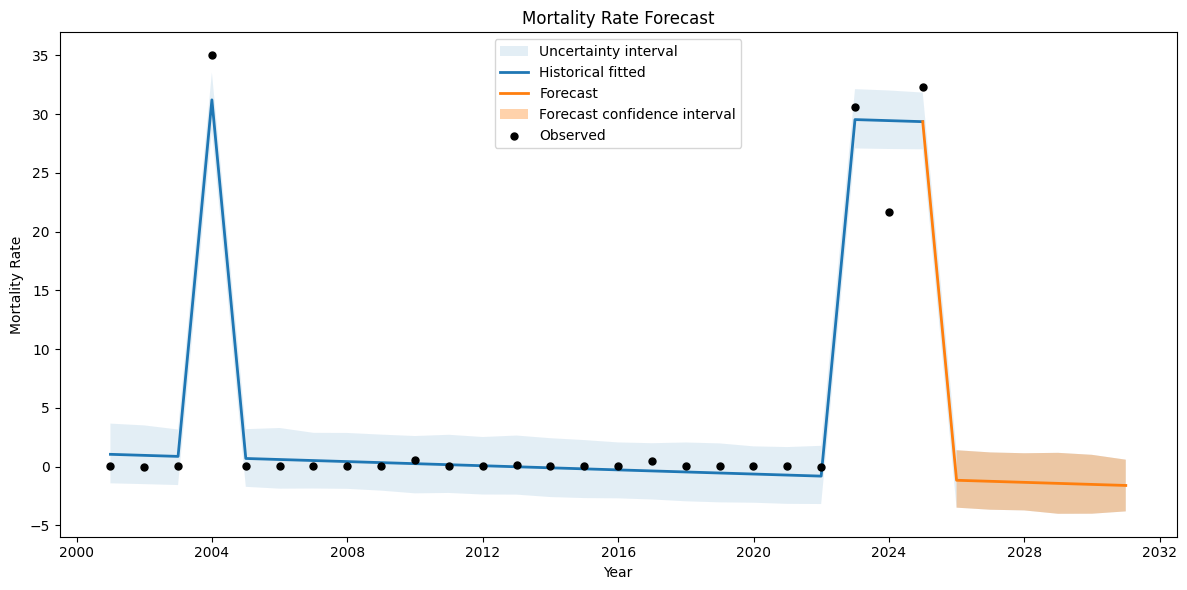

In [27]:
italy_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.5. Mexico

In [28]:
mexico = prepare_level_data(df,level='country', filter='Mexico')
mexico_model = ProphetModel(mexico)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2013,2017, 2024]
mexico_forecast = mexico_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(mexico_forecast)

23:11:40 - cmdstanpy - INFO - Chain [1] start processing
23:11:40 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.046040   -0.017507    0.109272
26 2026-12-31  0.045307   -0.017901    0.108974
27 2027-12-31  0.044574   -0.022154    0.109122
28 2028-12-31  0.043839   -0.021601    0.104607
29 2029-12-31  0.043106   -0.016816    0.108567
30 2030-12-31  0.042373   -0.020216    0.109156


23:11:40 - cmdstanpy - INFO - Chain [1] start processing
23:11:40 - cmdstanpy - INFO - Chain [1] done processing


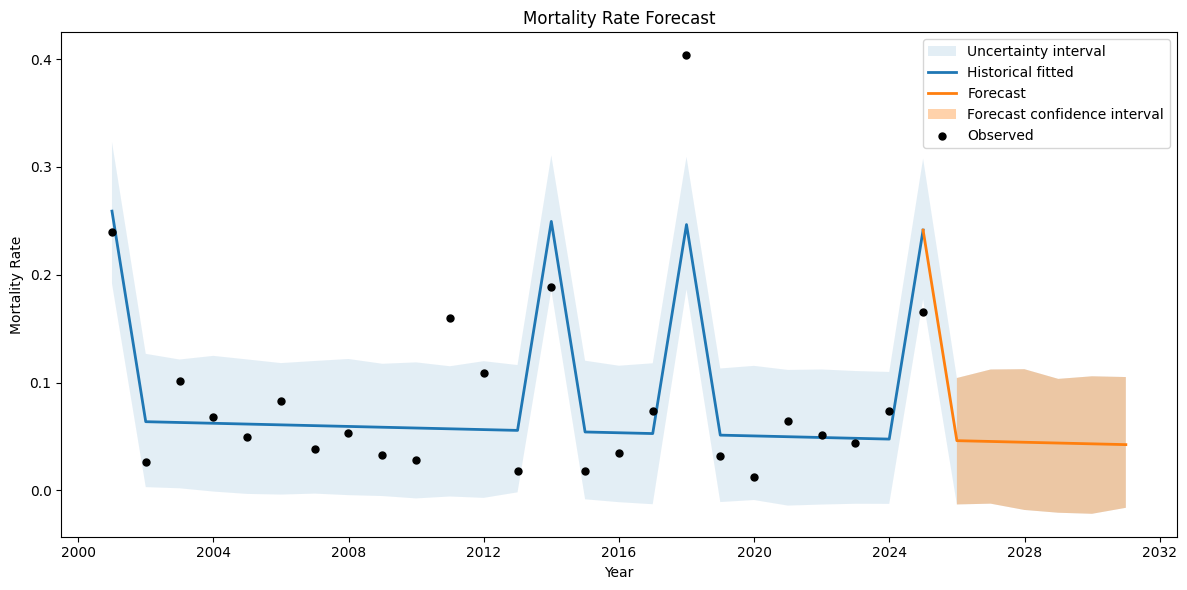

In [29]:
mexico_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.6. Sudan

In [30]:
sudan = prepare_level_data(df,level='country', filter='Sudan')
sudan_model = ProphetModel(sudan)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2005, 2006, 2007, 2017, 2024]
sudan_forecast = sudan_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(sudan_forecast)

23:11:41 - cmdstanpy - INFO - Chain [1] start processing
23:11:41 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.218265   -0.267693    0.700626
26 2026-12-31  0.217968   -0.266046    0.720918
27 2027-12-31  0.217672   -0.274736    0.680936
28 2028-12-31  0.217375   -0.276632    0.710460
29 2029-12-31  0.217079   -0.224041    0.747746
30 2030-12-31  0.216783   -0.290706    0.700047


23:11:41 - cmdstanpy - INFO - Chain [1] start processing
23:11:42 - cmdstanpy - INFO - Chain [1] done processing


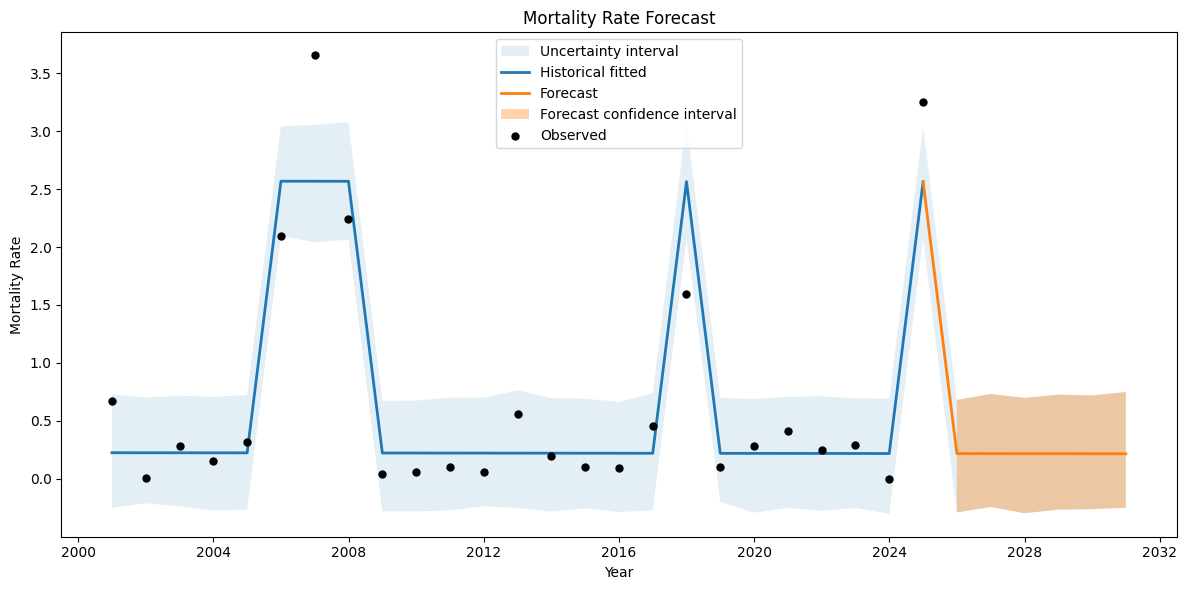

In [31]:
sudan_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.7. Türkiye

In [32]:
turkey = prepare_level_data(df,level='country', filter='Türkiye')
turkey_model = ARIMAModel(turkey)
turkey_forecast = turkey_model.arima_forecast(0, 0, 0, steps=6)
print(turkey_forecast)


Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              2.580184  12.167329     -21.267343      26.427711
26              2.580184  12.167329     -21.267343      26.427711
27              2.580184  12.167329     -21.267343      26.427711
28              2.580184  12.167329     -21.267343      26.427711
29              2.580184  12.167329     -21.267343      26.427711
30              2.580184  12.167329     -21.267343      26.427711


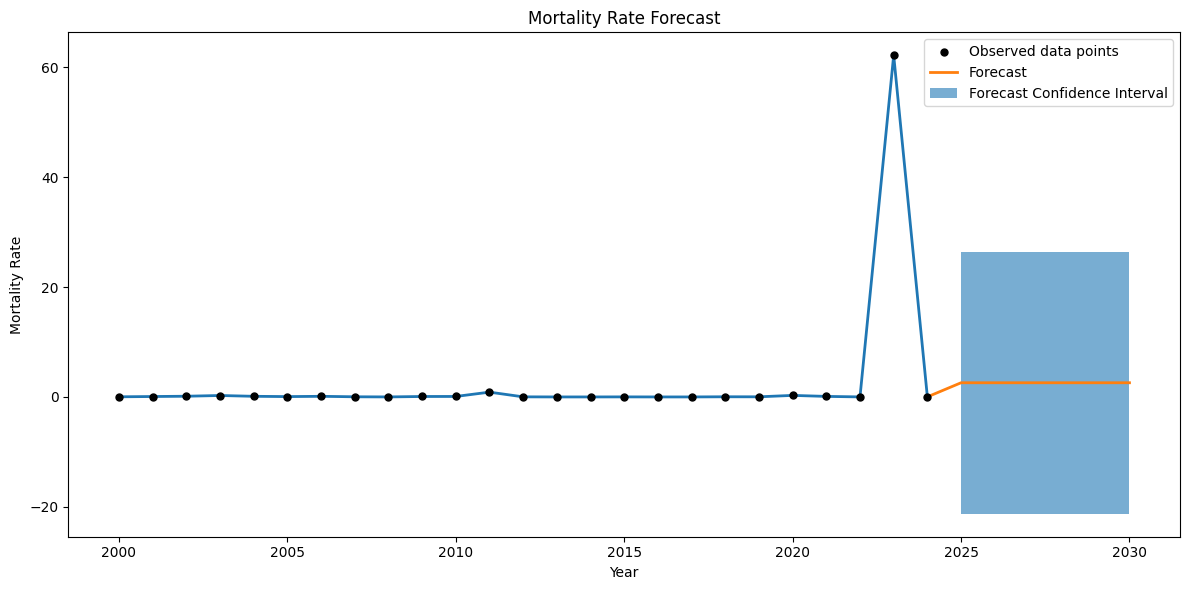

In [33]:
turkey_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.8. Canada

In [34]:
canada = prepare_level_data(df,level='country', filter='Canada')
canada_model = ProphetModel(canada)
best_params = {
    "changepoint_prior_scale": float(0.2),
    "holidays_prior_scale": float(15.0)}
holiday_years = [2018,2021]
canada_forecast = canada_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(canada_forecast)

23:11:43 - cmdstanpy - INFO - Chain [1] start processing
23:11:43 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.043866   -0.324920    0.415961
26 2026-12-31  0.046153   -0.313219    0.443634
27 2027-12-31  0.048441   -0.311460    0.393367
28 2028-12-31  0.050735   -0.309202    0.424351
29 2029-12-31  0.053023   -0.292270    0.400768
30 2030-12-31  0.055310   -0.301157    0.398679


23:11:43 - cmdstanpy - INFO - Chain [1] start processing
23:11:43 - cmdstanpy - INFO - Chain [1] done processing


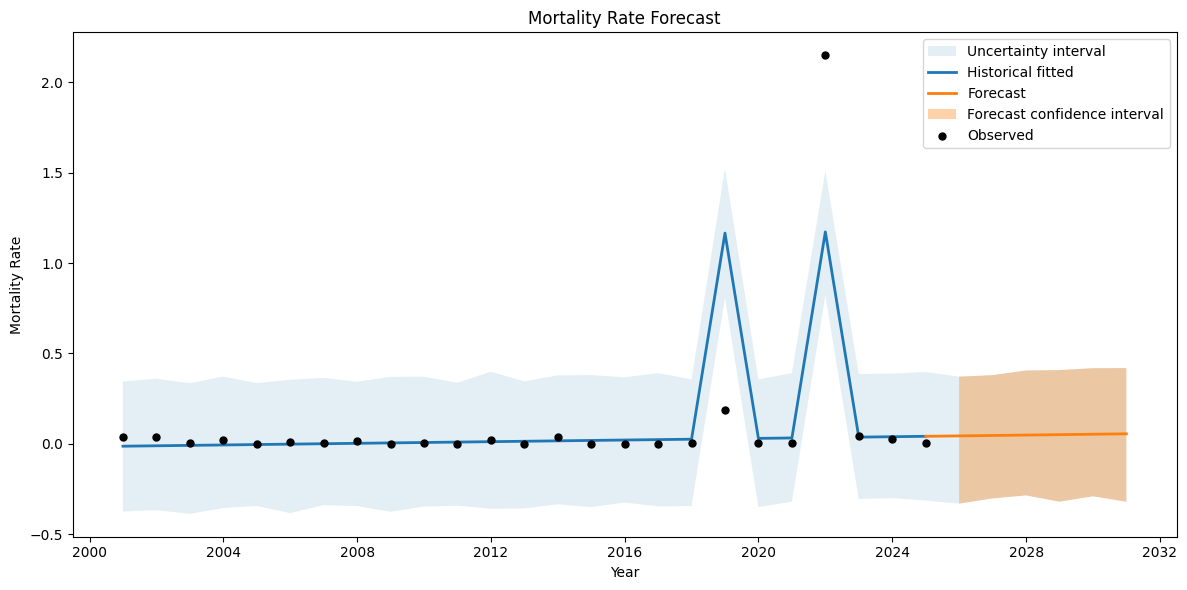

In [35]:
canada_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.9. United States of America

In [36]:
america = prepare_level_data(df,level='country', filter='United States of America')
america_model = ARIMAModel(america)
america_forecast = america_model.arima_forecast(1, 1, 0, steps=6)
print(america_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.306358  0.168145      -0.023200       0.635916
26              0.363364  0.191143      -0.011270       0.737997
27              0.337176  0.229149      -0.111947       0.786299
28              0.349206  0.254220      -0.149055       0.847467
29              0.343679  0.280091      -0.205289       0.892648
30              0.346218  0.302452      -0.246577       0.939014


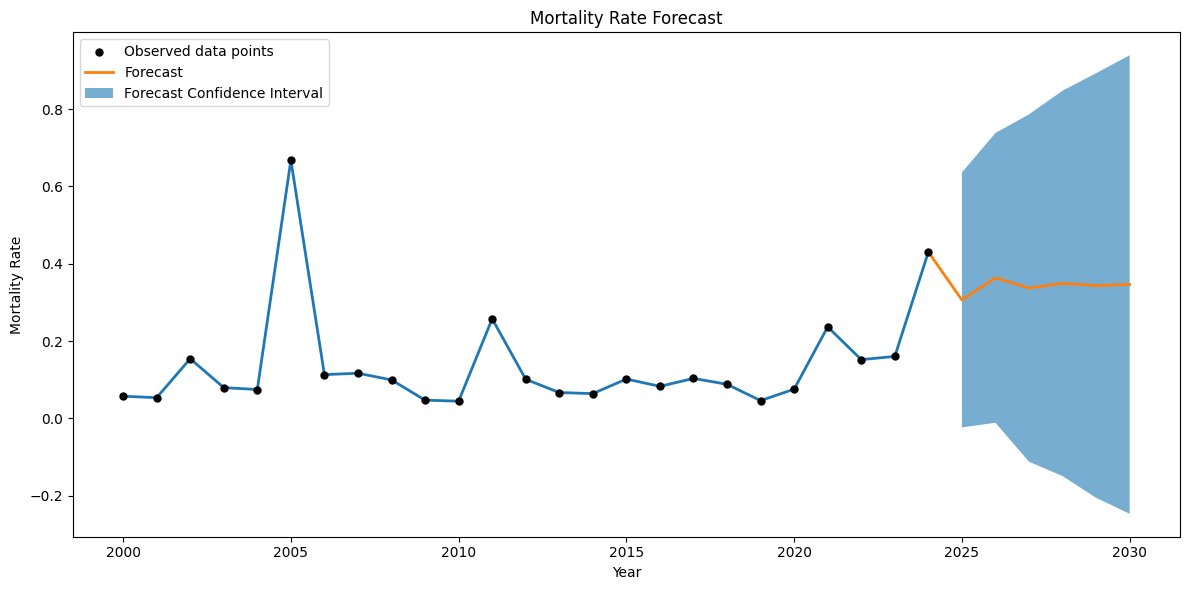

In [37]:
america_model.plot_forecast(1, 1, 0, steps=6)

### 2.3.10. India

In [38]:
india = prepare_level_data(df,level='country', filter='India')
india_model = ARIMAModel(india)
india_forecast = india_model.arima_forecast(1, 1, 1, steps=6)
print(india_forecast)

Mortality_Rate      mean   mean_se  mean_ci_lower  mean_ci_upper
25              0.152911  0.434764      -0.699210       1.005032
26              0.136374  0.434797      -0.715811       0.988560
27              0.141950  0.459991      -0.759616       1.043515
28              0.140070  0.471021      -0.783113       1.063253
29              0.140704  0.485526      -0.810909       1.092316
30              0.140490  0.498331      -0.836220       1.117201


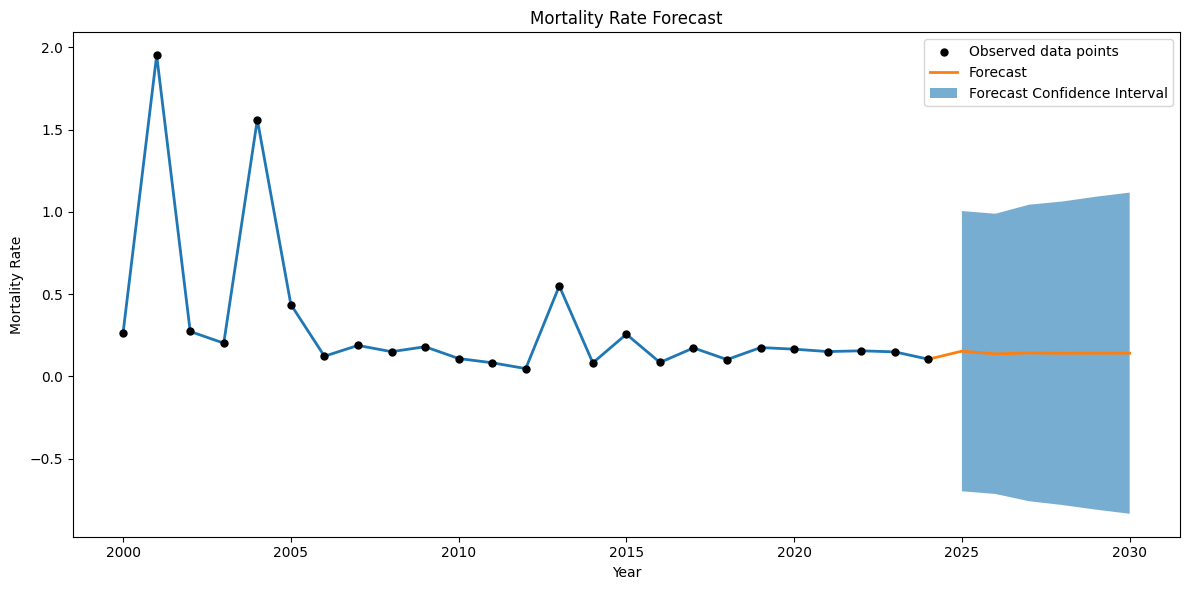

In [39]:
india_model.plot_forecast(1, 1, 1, steps=6)

### 2.3.11. Pakistan

In [40]:
pakistan = prepare_level_data(df,level='country', filter='Pakistan')
pakistan_model = ARIMAModel(pakistan)
pakistan_forecast = pakistan_model.arima_forecast(1, 1, 0, steps=6)
print(pakistan_forecast)

Mortality_Rate      mean    mean_se  mean_ci_lower  mean_ci_upper
25              0.295856  10.500717     -20.285170      20.876883
26              0.361395  11.804970     -22.775921      23.498712
27              0.329521  14.191978     -27.486246      28.145287
28              0.345023  15.681032     -30.389235      31.079281
29              0.337483  17.278861     -33.528462      34.203429
30              0.341150  18.632174     -36.177240      36.859541


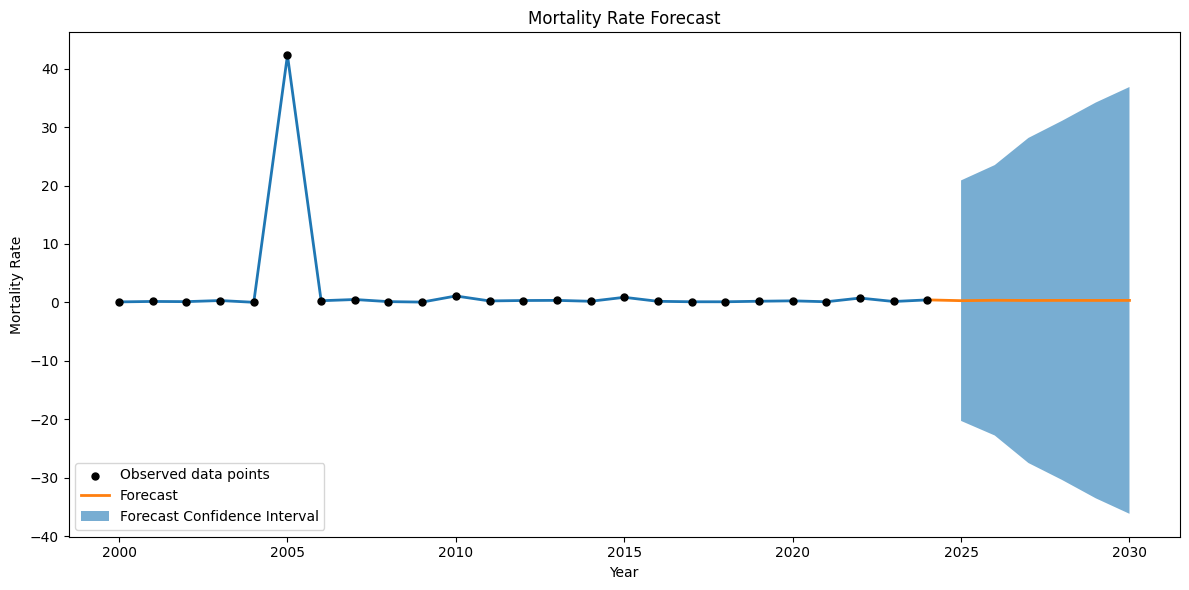

In [41]:
pakistan_model.plot_forecast(1, 1, 0, steps=6)

### 2.3.12. South Africa

In [42]:
south_africa = prepare_level_data(df,level='country', filter='South Africa')
south_africa_model = ProphetModel(south_africa)
best_params = {
    "changepoint_prior_scale": float(0.1),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2000,2002,2022]
south_africa_forecast = south_africa_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(south_africa_forecast)

23:11:45 - cmdstanpy - INFO - Chain [1] start processing
23:11:45 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.150038    0.030898    0.271721
26 2026-12-31  0.156912    0.041558    0.277573
27 2027-12-31  0.163786    0.034902    0.287715
28 2028-12-31  0.170680    0.039062    0.294381
29 2029-12-31  0.177554    0.061002    0.308140
30 2030-12-31  0.184428    0.059678    0.306708


23:11:45 - cmdstanpy - INFO - Chain [1] start processing
23:11:45 - cmdstanpy - INFO - Chain [1] done processing


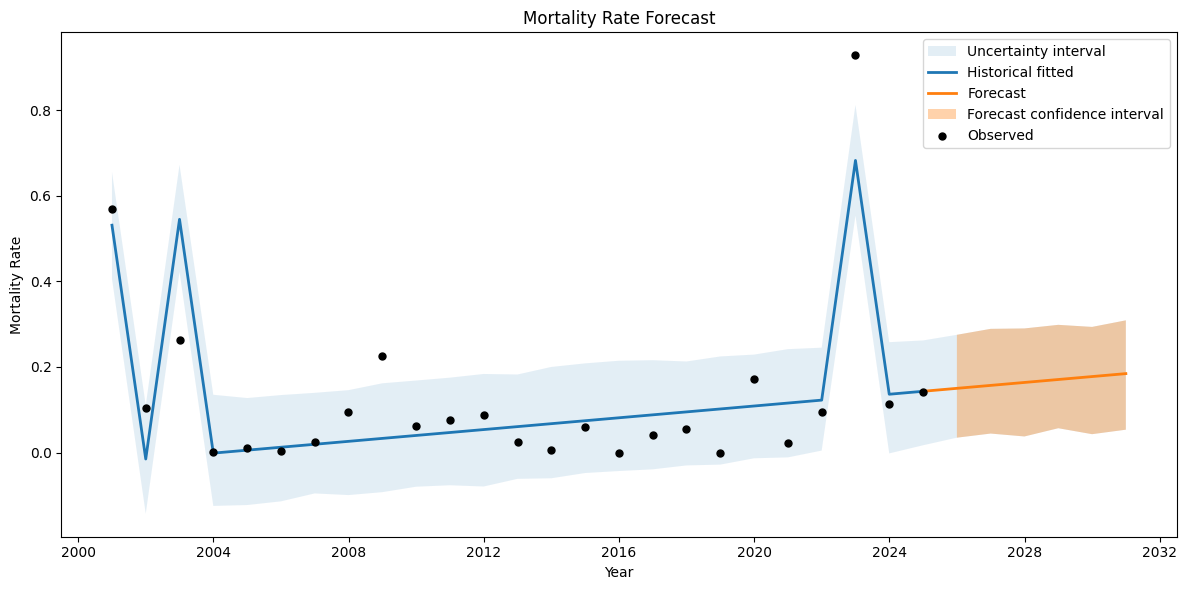

In [43]:
south_africa_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)

### 2.3.13. Kenya

In [44]:
kenya = prepare_level_data(df,level='country', filter='Kenya')
kenya_model = ARIMAModel(kenya)
kenya_forecast = kenya_model.arima_forecast(0, 0, 0, steps=6)

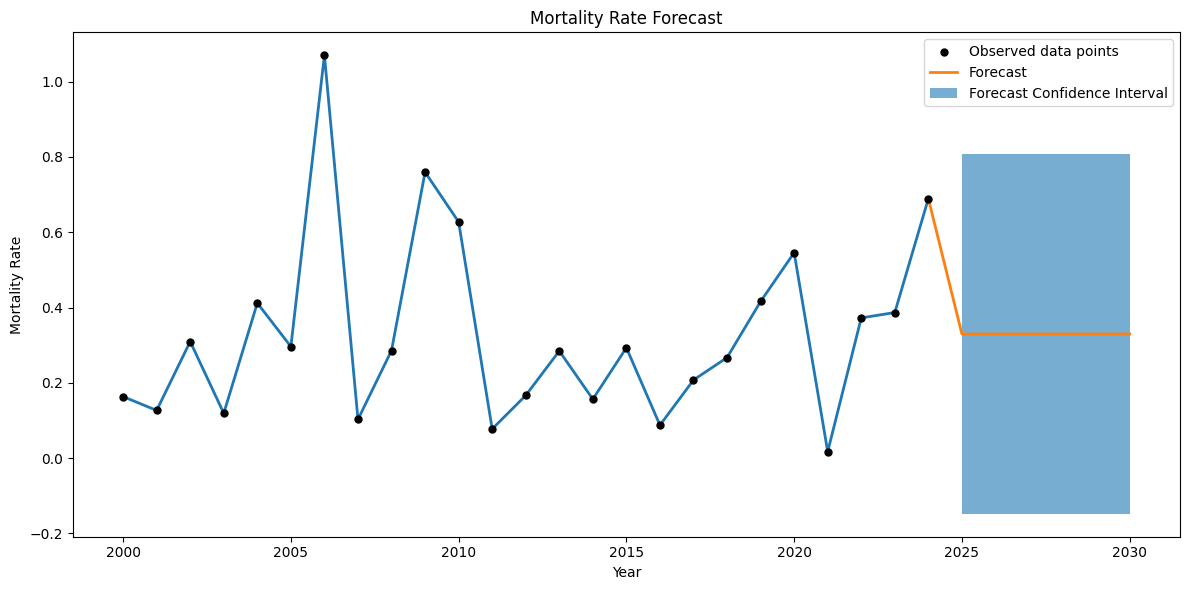

In [45]:
kenya_model.plot_forecast(0, 0, 0, steps=6)

### 2.3.14. Brazil

In [46]:
brazil = prepare_level_data(df,level='country', filter='Brazil')
brazil_model = ProphetModel(brazil)
best_params = {
    "changepoint_prior_scale": float(0.05),
    "holidays_prior_scale": float(15.0)
}
holiday_years = [2011]
brazil_forecast = brazil_model.prophet_forecast(steps=6,
    holiday_years=holiday_years,
    **best_params)
print(brazil_forecast)

23:11:46 - cmdstanpy - INFO - Chain [1] start processing
23:11:46 - cmdstanpy - INFO - Chain [1] done processing


           ds      yhat  yhat_lower  yhat_upper
25 2025-12-31  0.092598    0.016902    0.175857
26 2026-12-31  0.093814    0.009345    0.166914
27 2027-12-31  0.095030    0.015398    0.169564
28 2028-12-31  0.096249    0.020435    0.177094
29 2029-12-31  0.097465    0.015984    0.182636
30 2030-12-31  0.098682    0.021380    0.178460


23:11:47 - cmdstanpy - INFO - Chain [1] start processing
23:11:47 - cmdstanpy - INFO - Chain [1] done processing


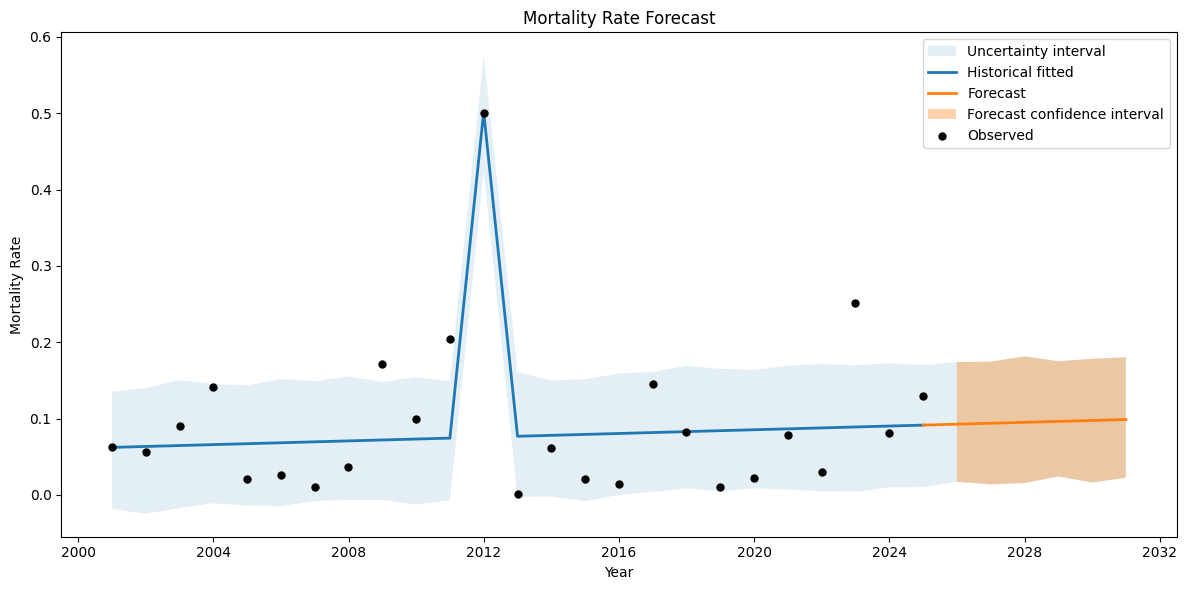

In [47]:
brazil_model.plot_forecast(steps=6, holiday_years=holiday_years, **best_params)